In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("../Indian Agricultural Mandi Prices (2023–2025)/Agriculture_price_dataset.csv")

In [4]:
print(df.head())
print(df.columns)

           STATE District Name        Market Name Commodity           Variety  \
0    Maharashtra        nashik  Lasalgaon(Niphad)     Wheat  Maharashtra 2189   
1    Maharashtra        satara              Patan    Tomato             Other   
2  Uttar Pradesh      mainpuri              Bewar    Potato             Local   
3      Rajasthan   chittorgarh          Nimbahera     Wheat             Other   
4      Rajasthan    pratapgarh         Pratapgarh     Onion             Other   

  Grade  Min_Price  Max_Price  Modal_Price  Price Date  
0   FAQ     2172.0     2399.0       2300.0  06-06-2023  
1   FAQ     1000.0     1500.0       1250.0  06-06-2023  
2   FAQ      800.0      820.0        810.0  06-06-2023  
3   FAQ     2040.0     2668.0       2300.0  06-06-2023  
4   FAQ      476.0     1043.0        617.0  06-06-2023  
Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date'],
      dtype='object')


In [5]:
df["Price Date"] = pd.to_datetime(
    df["Price Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [6]:
print(df["Price Date"].isna().sum())

0


In [7]:
df = df.sort_values("Price Date")
print(df.head())

               STATE District Name                                Market Name  \
41520         Punjab      amritsar              Amritsar(Amritsar Mewa Mandi)   
42559  Uttar Pradesh      mirzapur                                    Ahirora   
42558         Kerala    malappuram                                  Kottakkal   
42557  Uttar Pradesh       mathura                                  Kosikalan   
42556        Gujarat     ahmedabad  Ahmedabad(Chimanbhai Patal Market Vasana)   

      Commodity Variety Grade  Min_Price  Max_Price  Modal_Price Price Date  
41520    Tomato  Tomato   FAQ     1000.0     3000.0       2200.0 2023-01-07  
42559     Onion     Red   FAQ     1100.0     1350.0       1230.0 2023-01-07  
42558    Tomato   Other   FAQ     8600.0     8700.0       8650.0 2023-01-07  
42557    Tomato   Deshi   FAQ     4900.0     5040.0       5000.0 2023-01-07  
42556     Onion   Nasik   FAQ      800.0     1700.0       1450.0 2023-01-07  


In [8]:
print(df["Price Date"].head())
print(df["Price Date"].tail())

41520   2023-01-07
42559   2023-01-07
42558   2023-01-07
42557   2023-01-07
42556   2023-01-07
Name: Price Date, dtype: datetime64[ns]
700570   2025-12-05
700569   2025-12-05
700568   2025-12-05
700584   2025-12-05
701353   2025-12-05
Name: Price Date, dtype: datetime64[ns]


In [9]:
commodity = "Wheat"
market = "Lasalgaon(Niphad)"

df_crop = df[
    (df["Commodity"] == commodity) &
    (df["Market Name"] == market)
].copy()

print("Rows:", df_crop.shape[0])
print("Date Range:", df_crop["Price Date"].min(), "to", df_crop["Price Date"].max())

Rows: 179
Date Range: 2023-01-07 00:00:00 to 2024-12-01 00:00:00


In [10]:
df_crop = df_crop.set_index("Price Date")

weekly = df_crop["Modal_Price"].resample("W").mean().reset_index()

print("Weekly rows:", weekly.shape[0])
print(weekly.head())

Weekly rows: 100
  Price Date  Modal_Price
0 2023-01-08       2362.5
1 2023-01-15       2751.0
2 2023-01-22          NaN
3 2023-01-29          NaN
4 2023-02-05          NaN


In [11]:
weekly["Year"] = weekly["Price Date"].dt.year
weekly["Month"] = weekly["Price Date"].dt.month
weekly["Week"] = weekly["Price Date"].dt.isocalendar().week.astype(int)
weekly["Quarter"] = weekly["Price Date"].dt.quarter

In [12]:
weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
weekly["Lag_4"] = weekly["Modal_Price"].shift(4)
weekly["Rolling_4"] = weekly["Modal_Price"].rolling(4).mean()

weekly = weekly.dropna()

In [13]:
split_date = "2024-12-31"

train = weekly[weekly["Price Date"] <= split_date]
test = weekly[weekly["Price Date"] > split_date]

features = ["Year", "Month", "Week", "Quarter", "Lag_1", "Lag_4", "Rolling_4"]

X_train = train[features]
y_train = train["Modal_Price"]

X_test = test[features]
y_test = test["Modal_Price"]

In [14]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
print("Min date:", weekly["Price Date"].min())
print("Max date:", weekly["Price Date"].max())
print("Total rows:", weekly.shape[0])

Min date: 2023-07-09 00:00:00
Max date: 2024-02-04 00:00:00
Total rows: 26


In [16]:
split_index = int(len(weekly) * 0.8)

train = weekly.iloc[:split_index]
test = weekly.iloc[split_index:]

print("Train rows:", train.shape[0])
print("Test rows:", test.shape[0])

Train rows: 20
Test rows: 6


In [17]:
weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
weekly = weekly.dropna()

features = ["Lag_1"]

split_index = int(len(weekly) * 0.8)

train = weekly.iloc[:split_index]
test = weekly.iloc[split_index:]

X_train = train[features]
y_train = train["Modal_Price"]

X_test = test[features]
y_test = test["Modal_Price"]

In [18]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)
print("Mean Price:", y_test.mean())
print("RMSE %:", (rmse / y_test.mean()) * 100)

MAE: 170.1455729166667
RMSE: 201.73095512871168
Mean Price: 2798.366666666667
RMSE %: 7.208882150136807


In [20]:
df_crop = df[df["Commodity"] == "Wheat"].copy()

df_crop = df_crop.set_index("Price Date")

daily = df_crop["Modal_Price"].resample("D").mean().reset_index()

print("Daily rows:", daily.shape[0])

Daily rows: 695


In [22]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# ===============================
# PREPARE DATA
# ===============================

# Ensure date format
weekly["Price Date"] = pd.to_datetime(weekly["Price Date"])

# Sort data
weekly = weekly.sort_values("Price Date").reset_index(drop=True)

# Create lag features
weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
weekly["Lag_2"] = weekly["Modal_Price"].shift(2)
weekly["Lag_3"] = weekly["Modal_Price"].shift(3)

# Remove null rows
weekly = weekly.dropna().reset_index(drop=True)

# ===============================
# TRAIN MODEL
# ===============================

X = weekly[["Lag_1","Lag_2","Lag_3"]]
y = weekly["Modal_Price"]

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X,y)

print("Model trained successfully")

# ===============================
# FUTURE FORECAST
# ===============================

future_weeks = 8
last_known = weekly.copy()

future_predictions = []

for i in range(future_weeks):

    last_date = last_known["Price Date"].iloc[-1]
    next_date = last_date + pd.Timedelta(days=7)

    lag1 = last_known["Modal_Price"].iloc[-1]
    lag2 = last_known["Modal_Price"].iloc[-2]
    lag3 = last_known["Modal_Price"].iloc[-3]

    new_row = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3]
    })

    prediction = model.predict(new_row)[0]

    future_predictions.append((next_date,prediction))

    temp = pd.DataFrame({
        "Price Date":[next_date],
        "Modal_Price":[prediction]
    })

    last_known = pd.concat([last_known,temp],ignore_index=True)

# ===============================
# OUTPUT
# ===============================

future_df = pd.DataFrame(
    future_predictions,
    columns=["Date","Forecasted_Price"]
)

print("\nFuture Price Forecast:")
print(future_df)

Model trained successfully

Future Price Forecast:
        Date  Forecasted_Price
0 2024-02-11       2538.012451
1 2024-02-18       2645.119873
2 2024-02-25       2608.097656
3 2024-03-03       2862.220215
4 2024-03-10       2813.305664
5 2024-03-17       2802.067139
6 2024-03-24       2735.375244
7 2024-03-31       2538.012451


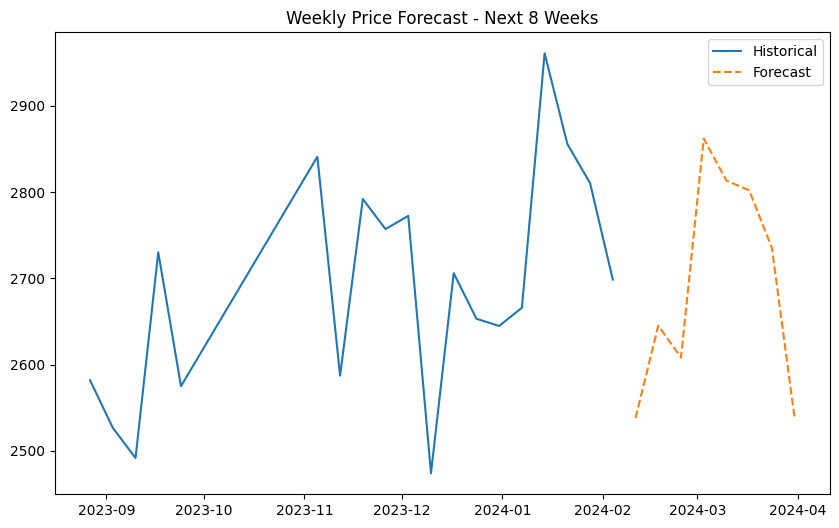

In [23]:
plt.figure(figsize=(10,6))
plt.plot(weekly["Price Date"], weekly["Modal_Price"], label="Historical")
plt.plot(future_df["Date"], future_df["Forecasted_Price"], label="Forecast", linestyle="--")
plt.legend()
plt.title("Weekly Price Forecast - Next 8 Weeks")
plt.show()

Forecast Multiple Commodities Automatically

In [24]:
df["Price Date"] = pd.to_datetime(df["Price Date"], errors="coerce")
df = df.dropna(subset=["Price Date"])
df = df.sort_values("Price Date")

commodities = df["Commodity"].unique()

results = {}

In [25]:
def prepare_weekly_series(df, commodity):
    
    df_crop = df[df["Commodity"] == commodity].copy()
    
    df_crop = df_crop.set_index("Price Date")
    
    weekly = df_crop["Modal_Price"].resample("W").mean().reset_index()
    
    weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
    weekly = weekly.dropna()
    
    return weekly

In [26]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

for commodity in commodities:
    
    weekly = prepare_weekly_series(df, commodity)
    
    if len(weekly) < 30:
        continue
    
    split_index = int(len(weekly) * 0.8)
    
    train = weekly.iloc[:split_index]
    test = weekly.iloc[split_index:]
    
    X_train = train[["Lag_1"]]
    y_train = train["Modal_Price"]
    
    X_test = test[["Lag_1"]]
    y_test = test["Modal_Price"]
    
    model = XGBRegressor(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_percent = (rmse / y_test.mean()) * 100
    
    results[commodity] = rmse_percent

In [27]:
performance_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["RMSE_%"]
).sort_values("RMSE_%")

print(performance_df.head(3))

           RMSE_%
Wheat    1.185337
Potato  26.166305
Onion   27.757269


XGBoost vs ARIMA Comparison

In [28]:
from statsmodels.tsa.arima.model import ARIMA

def arima_forecast(series):
    
    split_index = int(len(series) * 0.8)
    
    train = series.iloc[:split_index]
    test = series.iloc[split_index:]
    
    model = ARIMA(train, order=(1,1,1))
    model_fit = model.fit()
    
    preds = model_fit.forecast(steps=len(test))
    
    rmse = np.sqrt(mean_squared_error(test, preds))
    return rmse, test.mean()

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

In [30]:
df = pd.read_csv("../Indian Agricultural Mandi Prices (2023–2025)/Agriculture_price_dataset.csv")

df["Price Date"] = pd.to_datetime(df["Price Date"], errors="coerce")
df = df.dropna(subset=["Price Date"])

df = df.sort_values("Price Date")

In [31]:
def prepare_weekly_series(df, commodity):
    
    df_crop = df[df["Commodity"] == commodity].copy()
    
    df_crop = df_crop.set_index("Price Date")
    
    weekly = df_crop["Modal_Price"].resample("W").mean().reset_index()
    
    weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
    
    weekly = weekly.dropna()
    
    return weekly

c:\Users\Hp\OneDrive\Desktop\hydrology_crop_decision_support\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Hp\OneDrive\Desktop\hydrology_crop_decision_support\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



=== MODEL COMPARISON (Top 10) ===
  Commodity   XGB_RMSE  ARIMA_RMSE
1    Potato  14.160080   30.354330
0     Onion  20.125172   88.803312


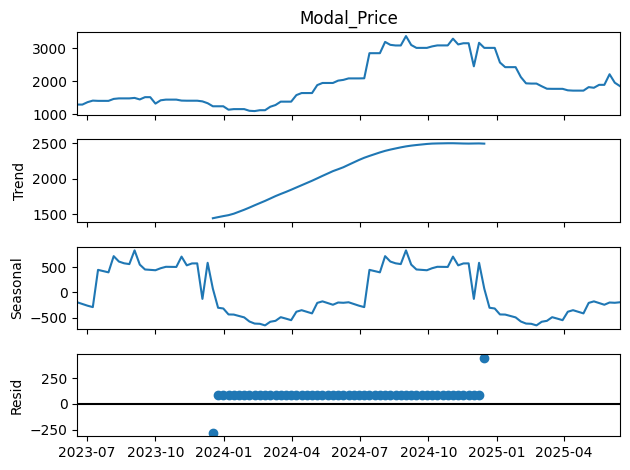


=== BEST MODEL PER COMMODITY ===
{'Potato': 'XGB', 'Onion': 'XGB'}

=== TOP PROFITABLE CROPS ===
        Expected_Profit
Potato      1726.920044
Onion       1674.584961


In [32]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose


# ============================================================
# 2️⃣ LOAD & CLEAN DATA
# ============================================================

df = pd.read_csv("../Indian Agricultural Mandi Prices (2023–2025)/Agriculture_price_dataset.csv")

df["Price Date"] = pd.to_datetime(df["Price Date"], errors="coerce")
df = df.dropna(subset=["Price Date"])
df = df.sort_values("Price Date")


# ============================================================
# 3️⃣ WEEKLY SERIES PREPARATION FUNCTION
# ============================================================

def prepare_weekly_series(df, commodity):
    
    df_crop = df[df["Commodity"] == commodity].copy()
    
    df_crop = df_crop.set_index("Price Date")
    
    weekly = df_crop["Modal_Price"].resample("W").mean()
    
    weekly = weekly.to_frame()
    
    # Force weekly frequency
    weekly = weekly.asfreq("W")
    
    # Forward fill missing weeks
    weekly["Modal_Price"] = weekly["Modal_Price"].ffill()
    
    # Create lag feature
    weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
    
    weekly = weekly.dropna()
    
    return weekly


# ============================================================
# 4️⃣ XGBOOST vs ARIMA COMPARISON
# ============================================================

comparison_results = []

for commodity in df["Commodity"].unique():
    
    weekly = prepare_weekly_series(df, commodity)
    
    if len(weekly) < 40:
        continue
    
    split_index = int(len(weekly) * 0.8)
    
    train = weekly.iloc[:split_index]
    test = weekly.iloc[split_index:]
    
    # ---------------- XGBOOST ----------------
    
    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.1,
        random_state=42
    )
    
    xgb_model.fit(train[["Lag_1"]], train["Modal_Price"])
    
    xgb_preds = xgb_model.predict(test[["Lag_1"]])
    
    xgb_rmse = np.sqrt(
        mean_squared_error(test["Modal_Price"], xgb_preds)
    )
    
    # ---------------- ARIMA ----------------
    
    arima_model = ARIMA(
        train["Modal_Price"],
        order=(1,1,1)
    )
    
    arima_fit = arima_model.fit()
    
    arima_preds = arima_fit.forecast(steps=len(test))
    
    arima_rmse = np.sqrt(
        mean_squared_error(test["Modal_Price"], arima_preds)
    )
    
    mean_price = test["Modal_Price"].mean()
    
    comparison_results.append({
        "Commodity": commodity,
        "XGB_RMSE": (xgb_rmse / mean_price) * 100,
        "ARIMA_RMSE": (arima_rmse / mean_price) * 100
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values("XGB_RMSE")

print("\n=== MODEL COMPARISON (Top 10) ===")
print(comparison_df.head(10))


# ============================================================
# 5️⃣ SEASONAL DECOMPOSITION (Example: Best Crop)
# ============================================================

best_crop = comparison_df.iloc[0]["Commodity"]

weekly_example = prepare_weekly_series(df, best_crop)

decomposition = seasonal_decompose(
    weekly_example["Modal_Price"],
    model="additive",
    period=52
)

decomposition.plot()
plt.show()


# ============================================================
# 6️⃣ SELECT BEST MODEL PER CROP
# ============================================================

best_model_per_crop = {}

for row in comparison_df.itertuples():
    
    if row.XGB_RMSE < row.ARIMA_RMSE:
        best_model_per_crop[row.Commodity] = "XGB"
    else:
        best_model_per_crop[row.Commodity] = "ARIMA"

print("\n=== BEST MODEL PER COMMODITY ===")
print(best_model_per_crop)


# ============================================================
# 7️⃣ FUTURE 4-WEEK FORECAST FUNCTION
# ============================================================

def forecast_next_4_weeks(commodity):
    
    weekly = prepare_weekly_series(df, commodity)
    
    model_type = best_model_per_crop.get(commodity, "XGB")
    
    split_index = int(len(weekly) * 0.8)
    train = weekly.iloc[:split_index]
    
    if model_type == "XGB":
        
        model = XGBRegressor(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.1,
            random_state=42
        )
        
        model.fit(train[["Lag_1"]], train["Modal_Price"])
        
        last_value = weekly["Modal_Price"].iloc[-1]
        future_prices = []
        
        for _ in range(4):
            pred = model.predict([[last_value]])[0]
            future_prices.append(pred)
            last_value = pred
        
        return np.mean(future_prices)
    
    else:
        
        arima_model = ARIMA(
            train["Modal_Price"],
            order=(1,1,1)
        )
        
        arima_fit = arima_model.fit()
        
        forecast = arima_fit.forecast(steps=4)
        
        return forecast.mean()


# ============================================================
# 8️⃣ PROFIT FORECASTING INTEGRATION
# ============================================================

# Replace with real yield predictions if available
yield_dict = {
    "Wheat": 3.2,
    "Rice": 3.8,
    "Maize": 2.9,
    "Soybean": 2.5
}

profit_results = {}

for commodity in best_model_per_crop.keys():
    
    forecast_price = forecast_next_4_weeks(commodity)
    
    yield_value = yield_dict.get(commodity, 1)
    
    expected_profit = yield_value * forecast_price
    
    profit_results[commodity] = expected_profit

profit_df = pd.DataFrame.from_dict(
    profit_results,
    orient="index",
    columns=["Expected_Profit"]
)

profit_df = profit_df.sort_values(
    "Expected_Profit",
    ascending=False
)

print("\n=== TOP PROFITABLE CROPS ===")
print(profit_df.head(10))